In [28]:
import numpy as np
import tclab
import time
from datetime import datetime
import os
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from package_DBR import FOPDT,SOPDT,SelectPath_RT,myRound,Bode
import package_DBR
import package12

In [29]:
nameFile = 'Data\Cleaned_data_Open_loop_experiment_on_MV_2025-03-10-14h08.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv(nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable) 

MV


# variables

In [30]:
global a,Kp,T1,T2,Tu,Tg,Ts
a = (0.529-0.367)#temp dif 
Kp = 0.529 #without unit
T1 = 98 #sec
T2 = 120 #sec
Tu = 45 #sec
Tg = 170 #sec



# Functions

# Broida1

In [31]:
def broida1(MV): 
    PV = FOPDT(MV,Kp,Tg,Tu,Ts)
    return PV

In [32]:
TSim = 720  # Simulation Time [s]
Ts = 1.0    # Sampling Period [s]

    # MV = []
    # MVPath = {0: 0, 1: 1, TSim: 1}

    # for i in TSim : 
    # SelectPath_RT(MVPath, TSim, MV)

(0.0, 1265.0)

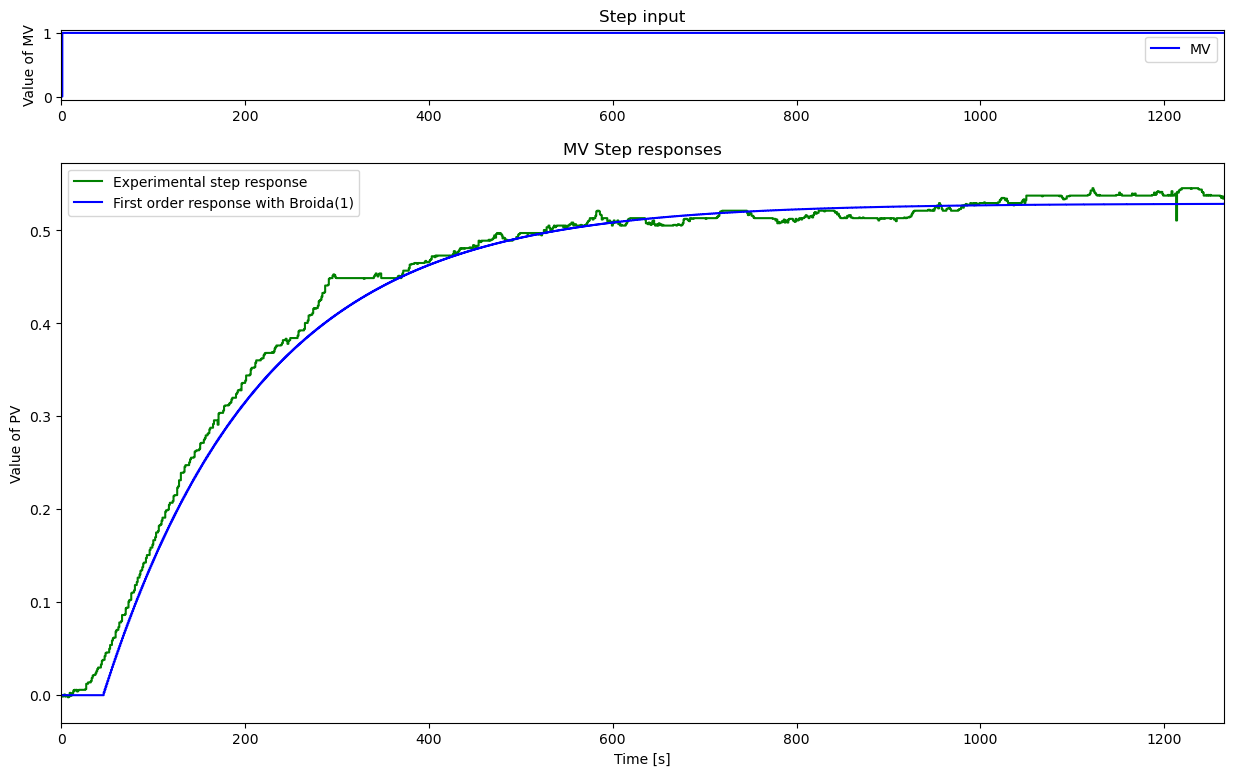

In [33]:

broida1 = broida1(MVm)

fig, axs = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={'height_ratios': [1, 8]})

axs[0].step(tm, MVm, 'b-', label='MV', where='post')
axs[0].set_ylabel('Value of MV')
axs[0].set_title('Step input')
axs[0].legend(loc='best')
axs[0].set_xlim([0, np.max(tm)])

axs[1].step(tm, PVm, 'g-', label='Experimental step response', where='post')
#axs[1].step(tm, PV_OMV_FOPDT, 'cyan', label='First order response with optimal parameters', where='post')
#axs[1].step(tm, PV_OMV_SOPDT, 'lime', label='Second order response with optimal parameters', where='post')
axs[1].step(tm, broida1, 'b-', label='First order response with Broida(1)', where='post')
#axs[1].step(tm, PV_G, 'r-', label='Second order response with van der Grinten', where='post')
axs[1].set_ylabel('Value of PV')
axs[1].set_xlabel('Time [s]')
axs[1].set_title('MV Step responses')
axs[1].legend(loc='best')
axs[1].set_xlim([0, np.max(tm)])

In [ ]:
t = []
MV = []
PV = []
DV = []
# Save data in text file
# ----------------------
now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")
# Conversion to array
t = np.array(t) 
MV = np.array(MV)
PV = np.array(PV)
DV = np.array(DV)        
my_data = np.vstack((t.T,MV.T,PV.T,DV.T))
my_data = my_data.T
nameFile = 'Data/RT_test_on_' + date_time + '.txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile,my_data,delimiter=',',header='t,MV,PV,DV',comments='')        


# Save Plot
# ---------
if not os.path.exists('Plots'):
    os.makedirs('Plots')

titleName = 'RT_test_on_' + date_time
plt.savefig('Plots\\' + titleName + '.png',transparent=True)
plt.savefig('Plots\\' + titleName + '.pdf',transparent=True)  
    

NameError: name 'PV' is not defined